In [6]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation
from agent import select_action, clever_single_action

%reload_ext autoreload
%autoreload 2

In [7]:
# Init policy Network

from agent import PolicyNet

obs_shape = (3, 5, 5)
policy_net = PolicyNet(obs_shape)
policy_net.load_state_dict(torch.load('policy_net.pth'))
policy_net.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net.to(device)


/home/delsad/SHS-Life-Science-Philosophy-Altruism/grid_simulation/cuda_env_project/.pixi/envs/default/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


PolicyNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=75, out_features=100, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=17, bias=True)
)

In [8]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        if type1 == 'Reinforcement Learning Agent':
            action_grid = simulation.configurable_actions_grid(type1=None, type2=type2, type3=type3)

            with torch.no_grad():
                observations, obs_indices = simulation.get_deep_observations(0)
                action = select_action(policy_net, observations)
                action_grid = clever_single_action(simulation, action, obs_indices, type2, type3) 

        else:
            action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)

        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'{type1.capitalize()}'),
        Patch(facecolor='blue', edgecolor='b', label=f'{type2.capitalize()}'),
        Patch(facecolor='green', edgecolor='g', label=f'{type3.capitalize()}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final Population Distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'{type1.capitalize()}', color='red', linestyle='--', marker='o', markersize=4, markevery=10)
    plt.plot(np.arange(iterations), pop2_size, label=f'{type2.capitalize()}', color='blue', marker='x', markersize=4, markevery=7)
    plt.plot(np.arange(iterations), pop3_size, label=f'{type3.capitalize()}', color='green', marker='s', markersize=4, markevery=13)
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'


/tmp/ipykernel_668316/3466859960.py:5: SyntaxWarning: invalid escape sequence '\%'
  all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'


Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.45905303955078
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.45905303955078

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



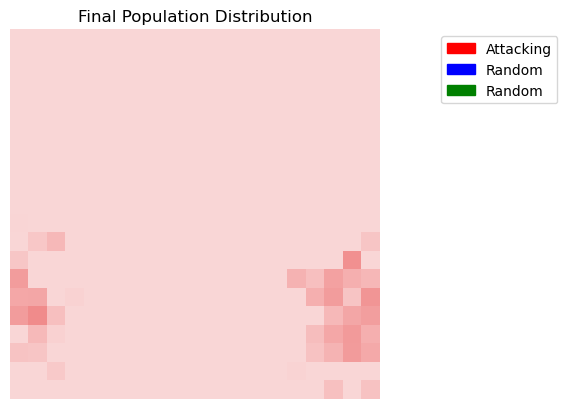

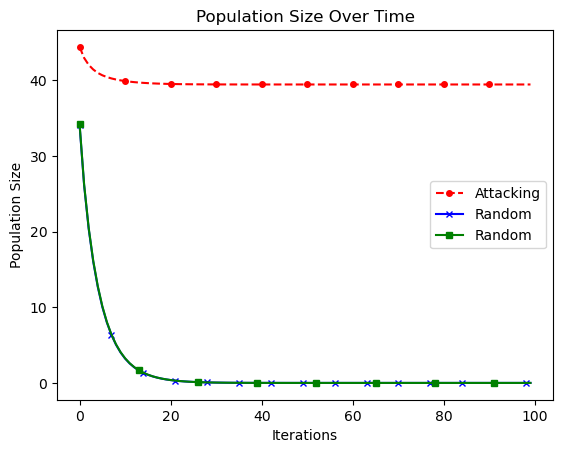

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 7.494199962820858e-07
Population 2: random - 1.1789029485953506e-05
Population 3: random - 1.1682645890687127e-05

Total fitness: 2.422109537292272e-05

Final population %'s fitness:
Population 1: giving - 3.09%
Population 2: random - 48.67%
Population 3: random - 48.23%



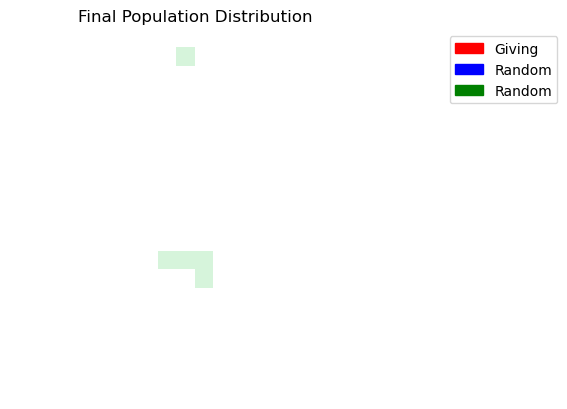

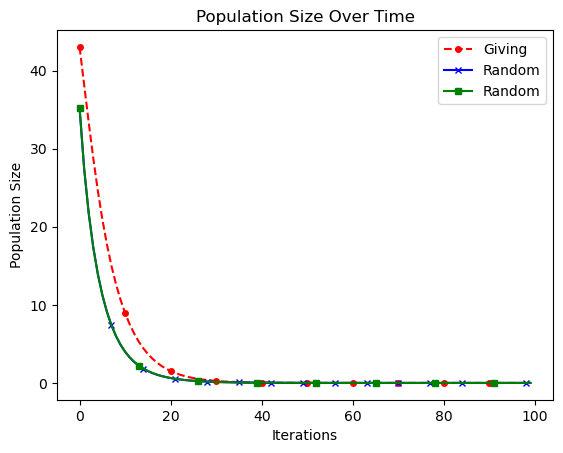

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 1.2874500043835724e-07
Population 2: random - 6.041522738087224e-06
Population 3: random - 5.907272679905873e-06

Total fitness: 1.2077540304744616e-05

Final population %'s fitness:
Population 1: complete - 1.07%
Population 2: random - 50.02%
Population 3: random - 48.91%



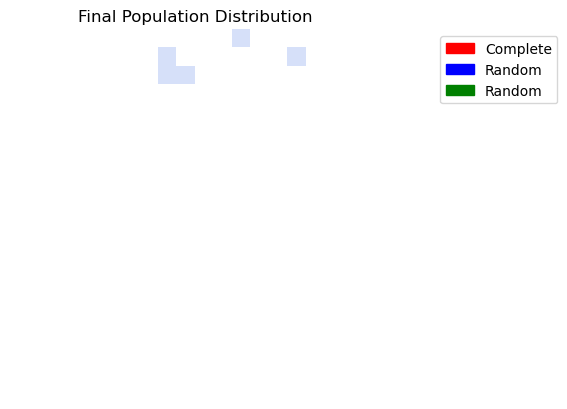

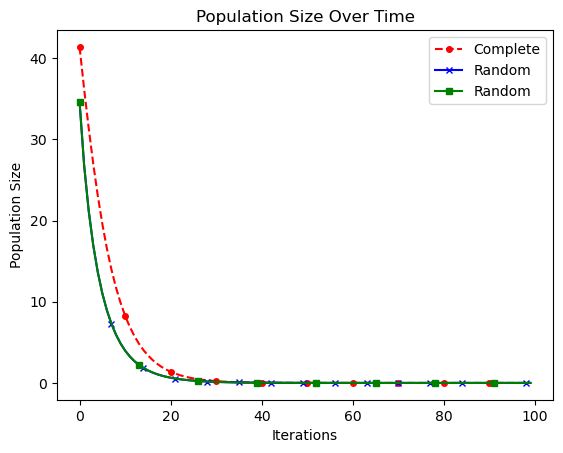

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 33.622684478759766

Total fitness: 33.622684478759766

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



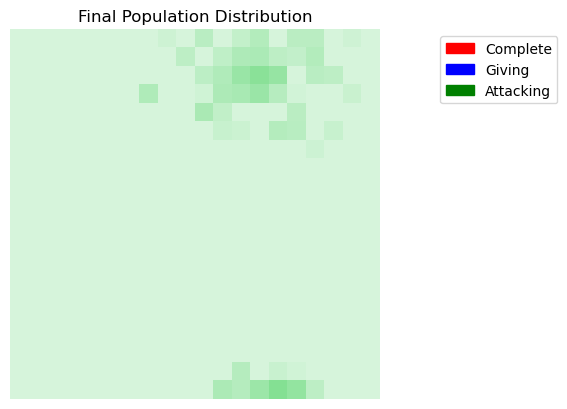

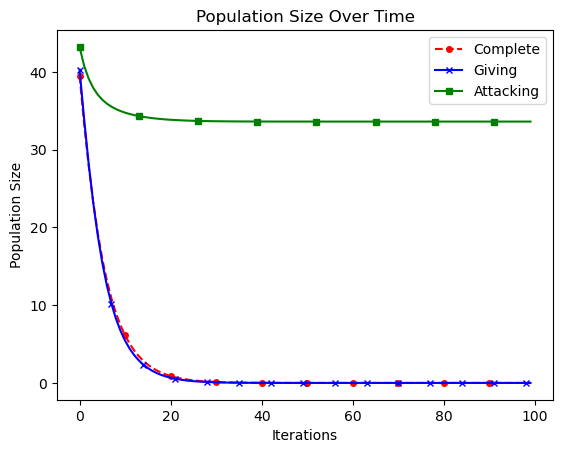

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38474621772766116..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.49414825439453
Population 2: random - 8.761746357777156e-06
Population 3: random - 8.04538376542041e-06

Total fitness: 44.494163513183594

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



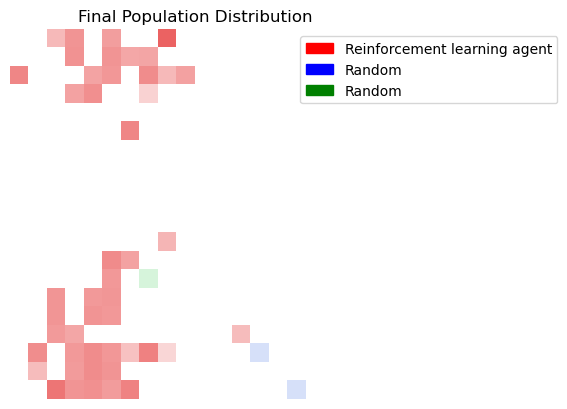

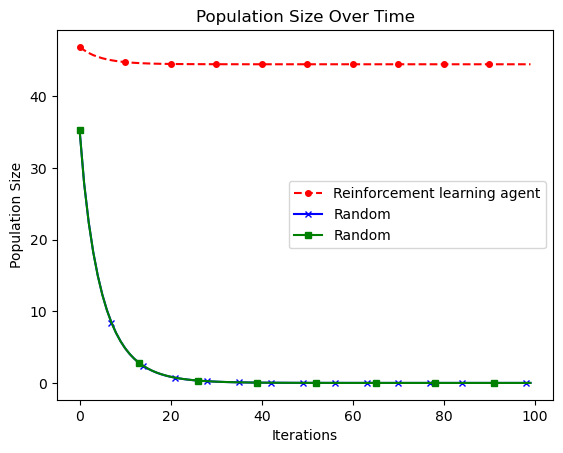

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5353006839752197..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 47.41685104370117
Population 2: giving - 0.042621128261089325
Population 3: giving - 0.04192367568612099

Total fitness: 47.50139617919922

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.82%
Population 2: giving - 0.09%
Population 3: giving - 0.09%



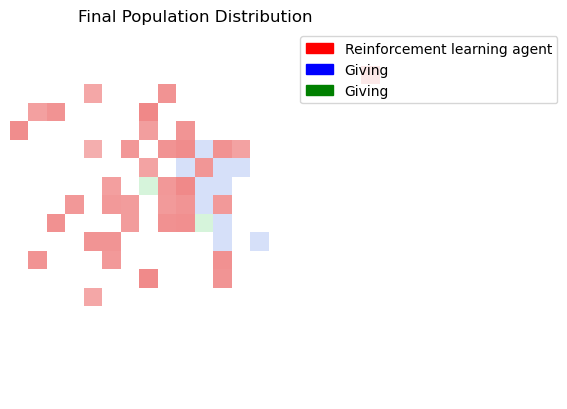

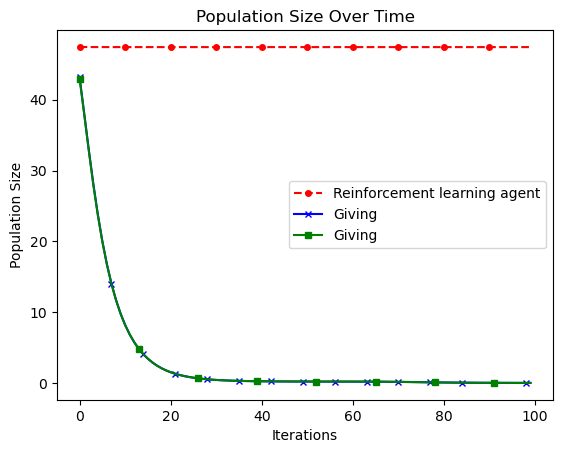

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4717561721801758..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 21.06650733947754
Population 2: attacking - 26.53736114501953
Population 3: attacking - 26.4993896484375

Total fitness: 74.10325622558594

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.43%
Population 2: attacking - 35.81%
Population 3: attacking - 35.76%



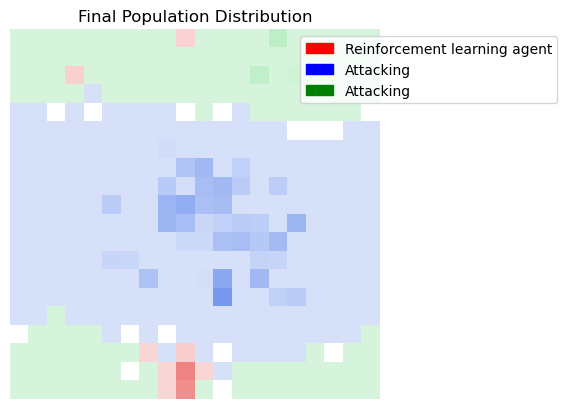

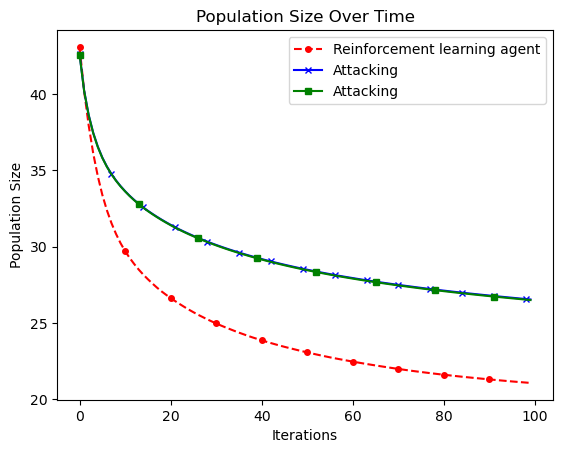

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3619.05419921875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3619.05419921875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



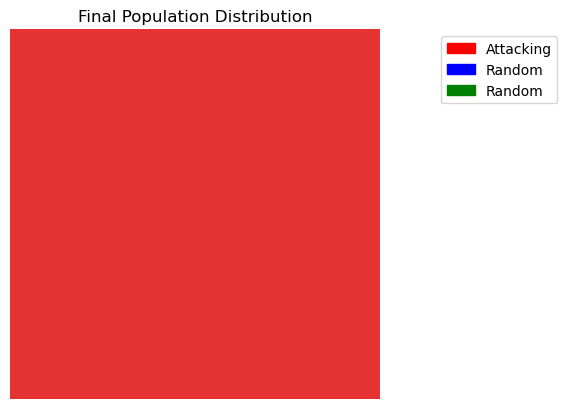

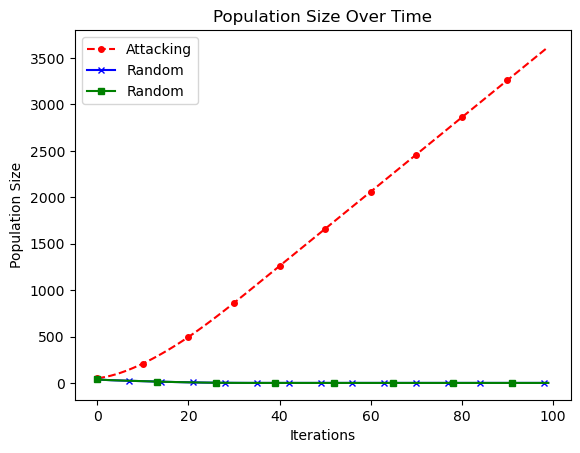

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 225.02365112304688
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 225.02365112304688

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



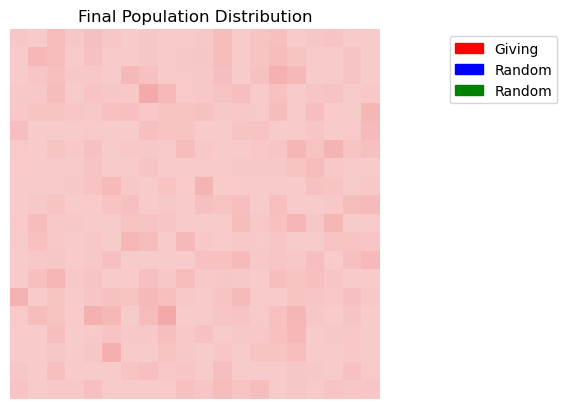

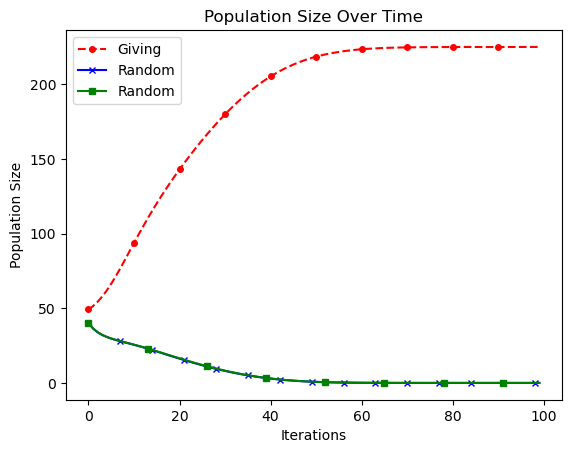

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.99468994140625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.99468994140625

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



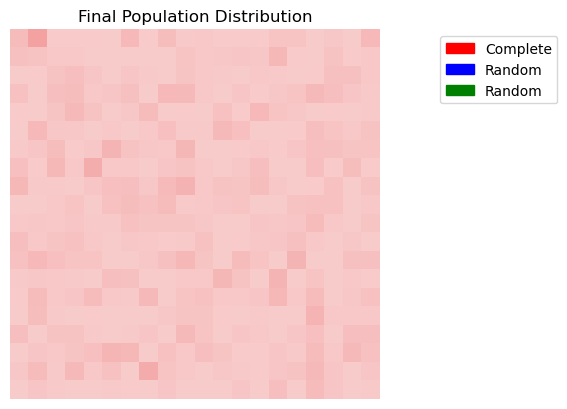

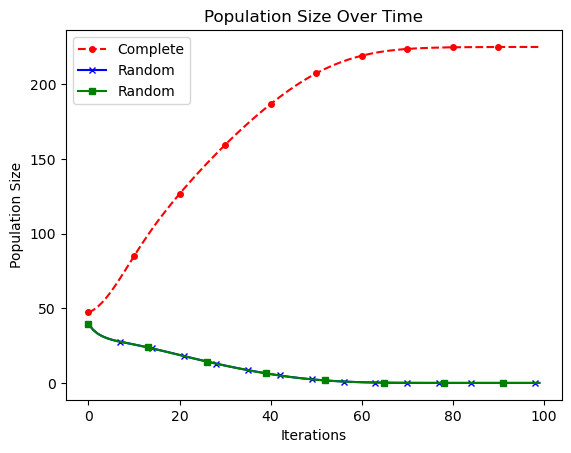

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.03755994886159897
Population 2: giving - 0.017451491206884384
Population 3: attacking - 3017.44580078125

Total fitness: 3017.500732421875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



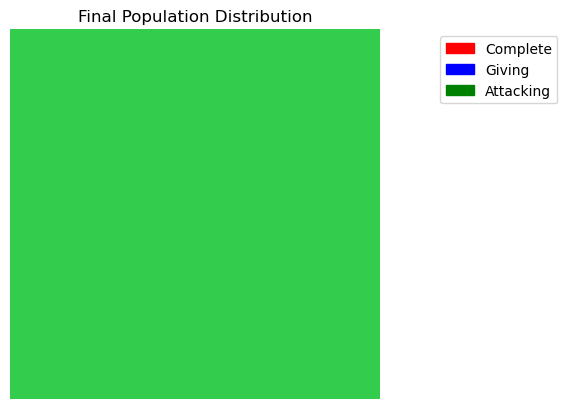

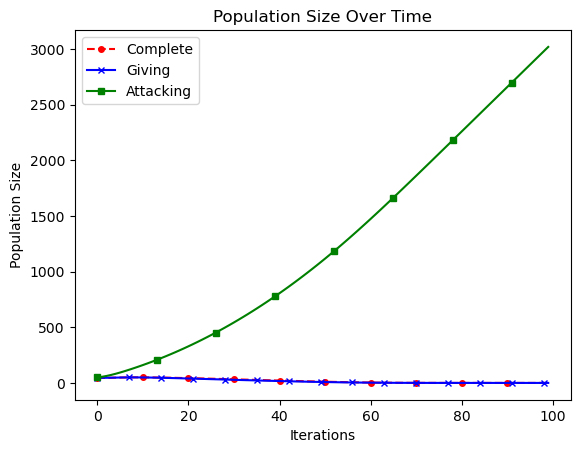

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 445.9884948730469
Population 2: random - 45.59870529174805
Population 3: random - 45.12053680419922

Total fitness: 536.7077026367188

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.10%
Population 2: random - 8.50%
Population 3: random - 8.41%



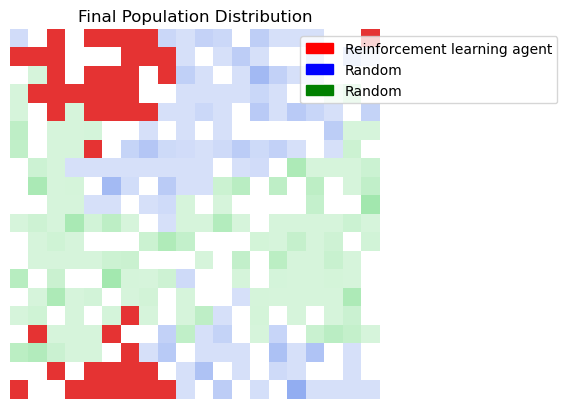

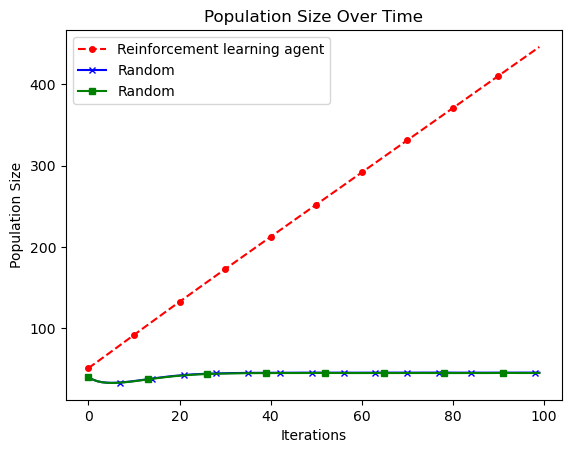

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 517.706787109375
Population 2: giving - 107.65039825439453
Population 3: giving - 107.5543212890625

Total fitness: 732.9114990234375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 70.64%
Population 2: giving - 14.69%
Population 3: giving - 14.67%



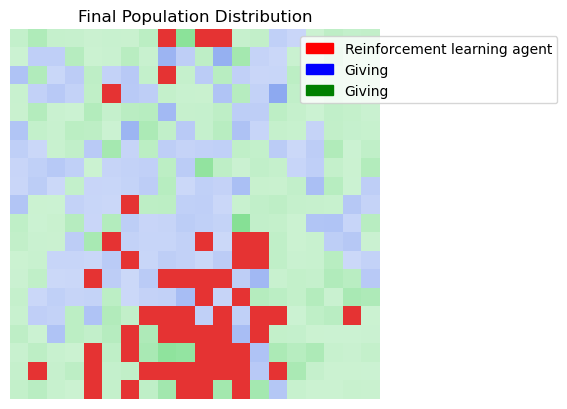

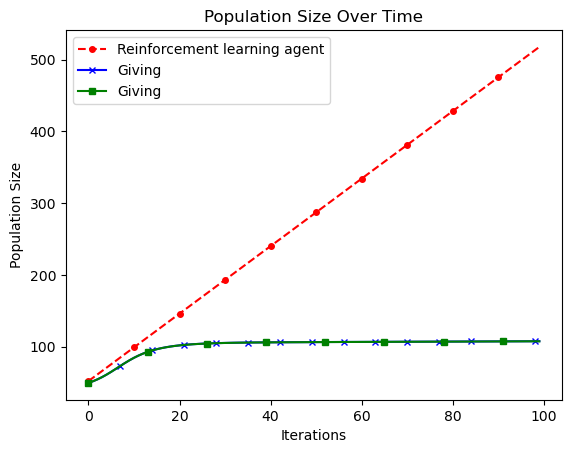

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.7514322400093079
Population 2: attacking - 1275.0633544921875
Population 3: attacking - 1269.419677734375

Total fitness: 2545.234375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.03%
Population 2: attacking - 50.10%
Population 3: attacking - 49.87%



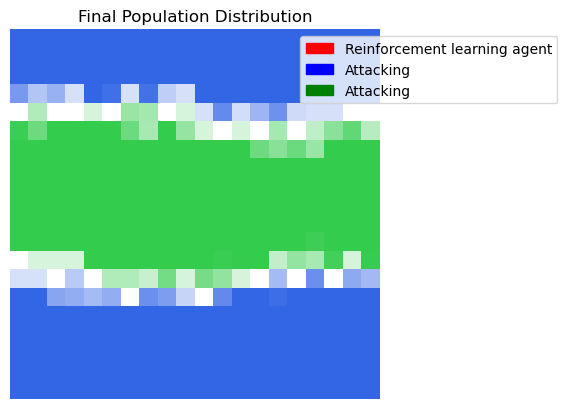

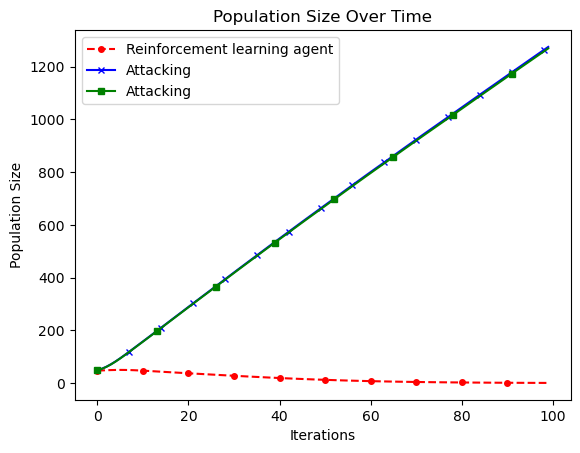

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.28483200073242
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.28483200073242

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



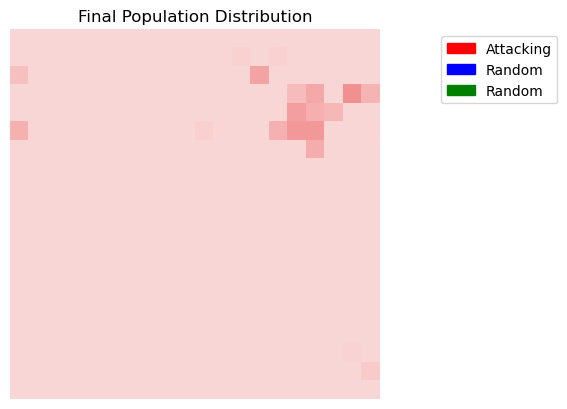

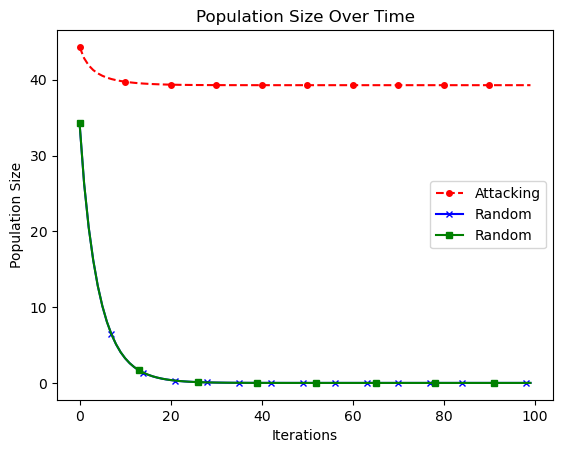

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 7.541420927736908e-07
Population 2: random - 1.1818003258667886e-05
Population 3: random - 1.2203351616335567e-05

Total fitness: 2.4775497877271846e-05

Final population %'s fitness:
Population 1: giving - 3.04%
Population 2: random - 47.70%
Population 3: random - 49.26%



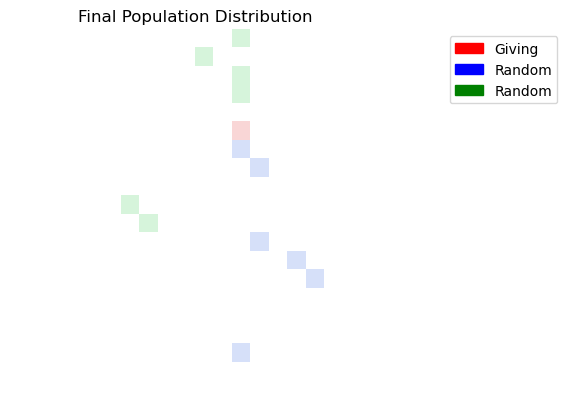

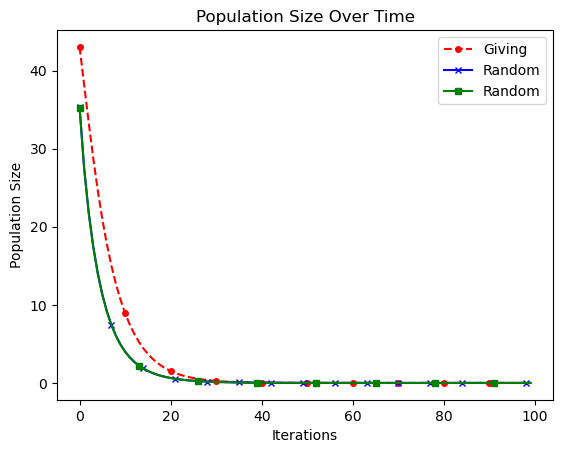

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 1.1461870741413804e-07
Population 2: random - 6.1470123000617605e-06
Population 3: random - 6.131722784630256e-06

Total fitness: 1.2393353244988248e-05

Final population %'s fitness:
Population 1: complete - 0.92%
Population 2: random - 49.60%
Population 3: random - 49.48%



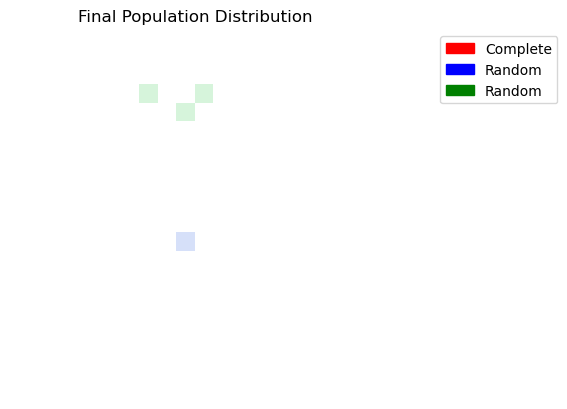

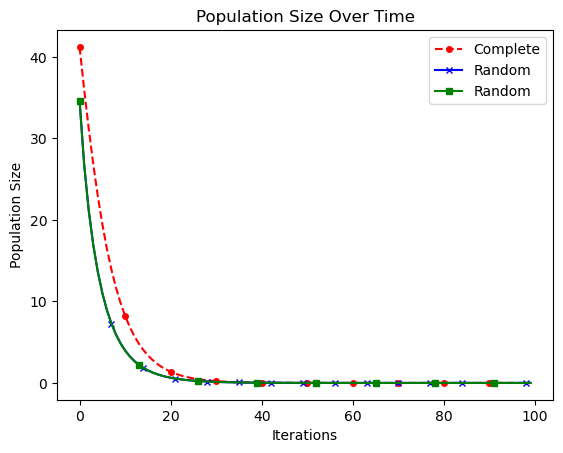

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 33.241432189941406

Total fitness: 33.241432189941406

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



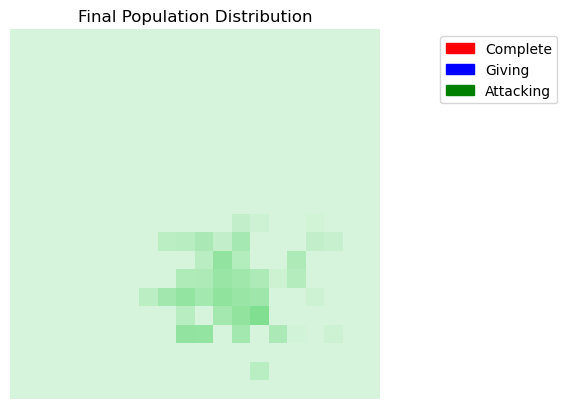

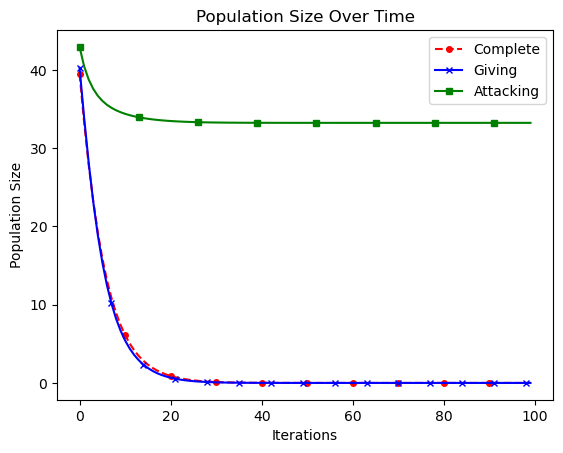

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.43798627853393557..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.26914596557617
Population 2: random - 7.511329386034049e-06
Population 3: random - 7.752647434244864e-06

Total fitness: 44.269161224365234

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



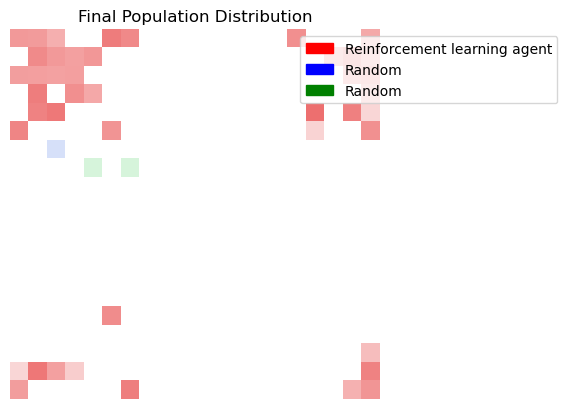

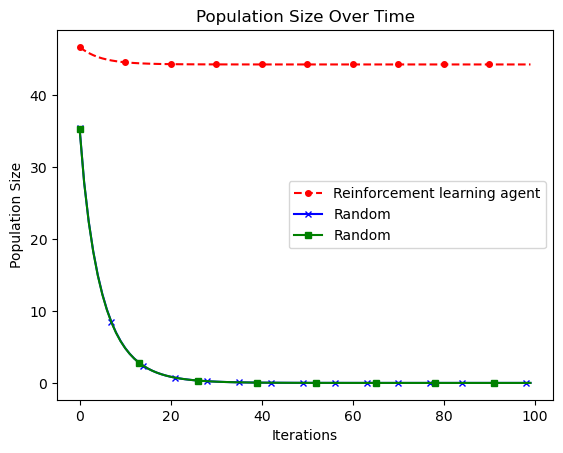

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.506365156173706..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 47.41606140136719
Population 2: giving - 0.042373672127723694
Population 3: giving - 0.04286224767565727

Total fitness: 47.50129699707031

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.82%
Population 2: giving - 0.09%
Population 3: giving - 0.09%



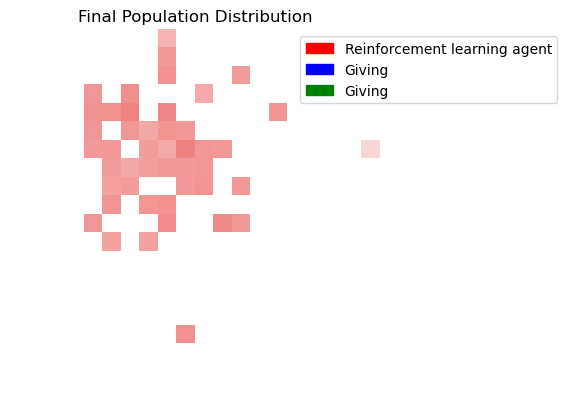

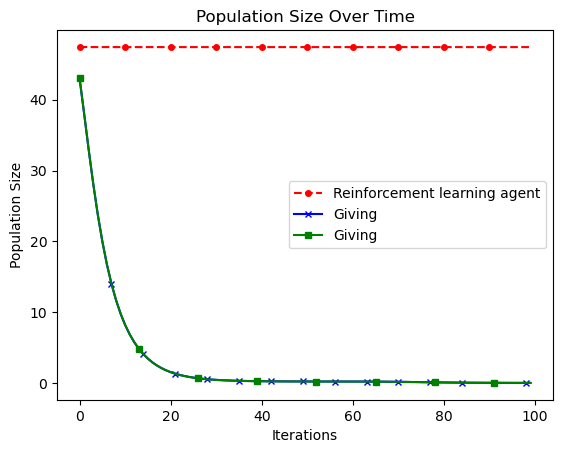

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38673086166381837..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 21.34154510498047
Population 2: attacking - 26.452199935913086
Population 3: attacking - 26.287761688232422

Total fitness: 74.08151245117188

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.81%
Population 2: attacking - 35.71%
Population 3: attacking - 35.48%



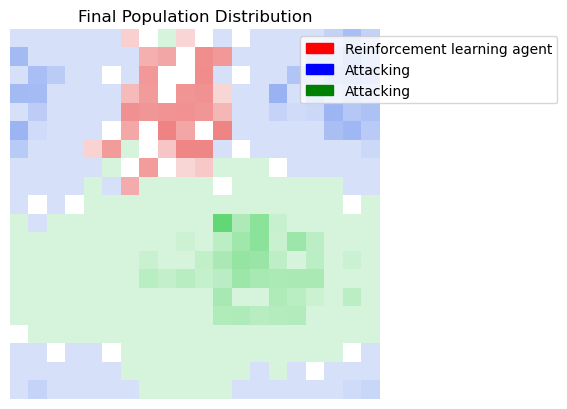

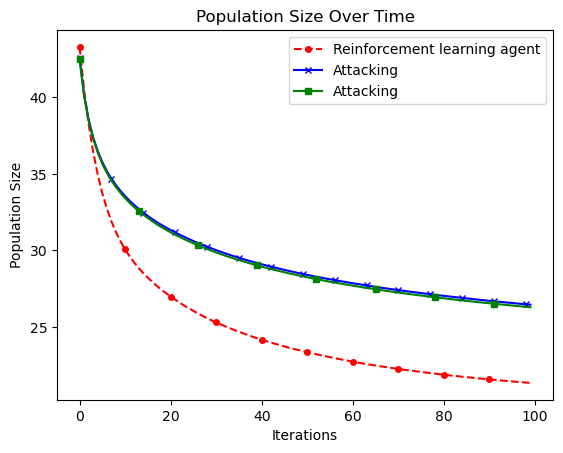

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3618.252685546875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3618.252685546875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



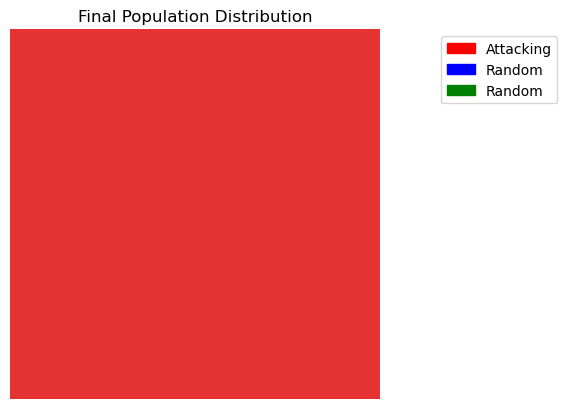

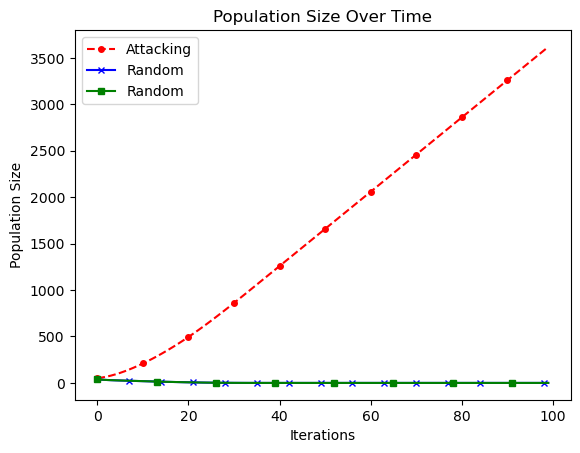

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 224.98744201660156
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.98744201660156

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



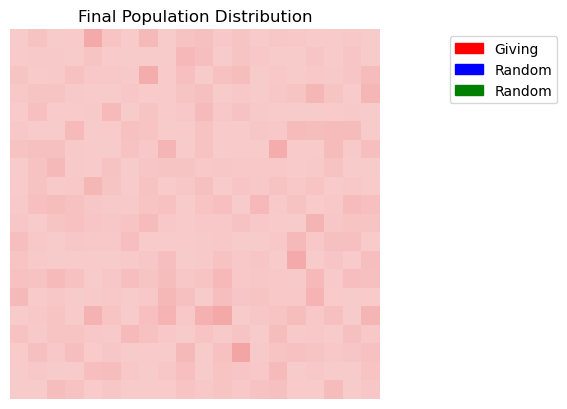

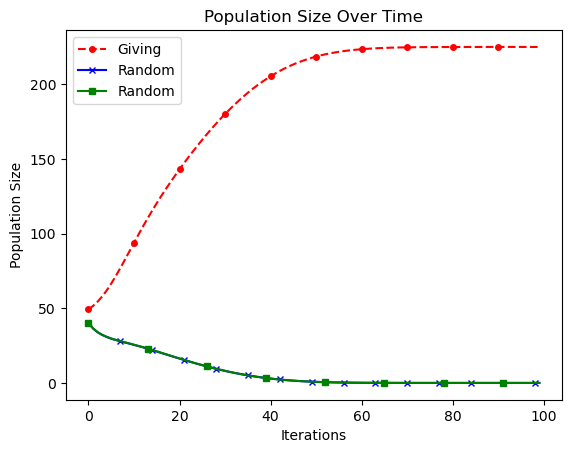

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.9927978515625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.9927978515625

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



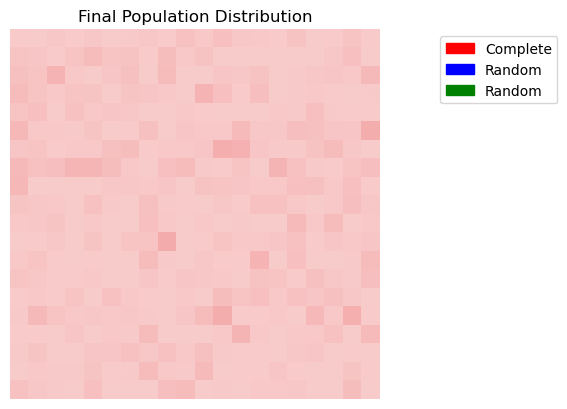

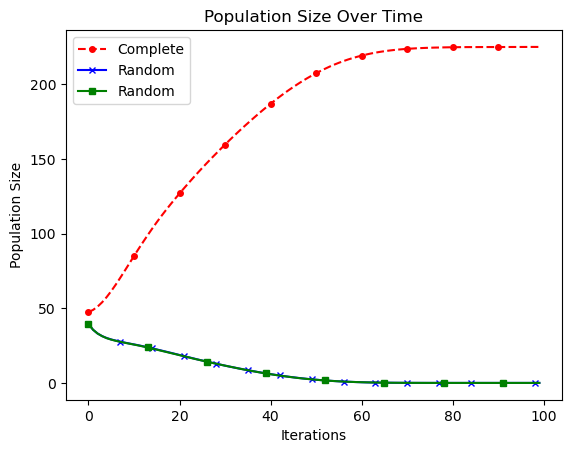

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.002797391265630722
Population 2: giving - 0.001488884212449193
Population 3: attacking - 3018.3525390625

Total fitness: 3018.35693359375

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



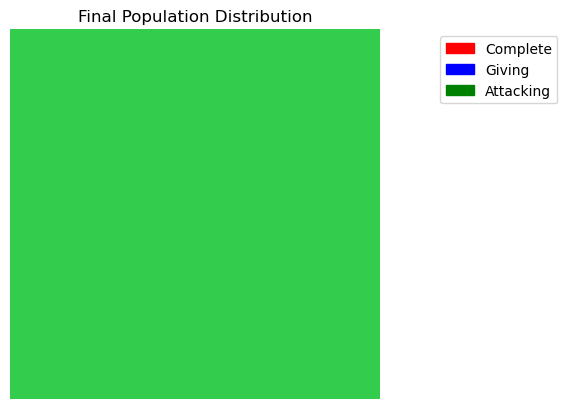

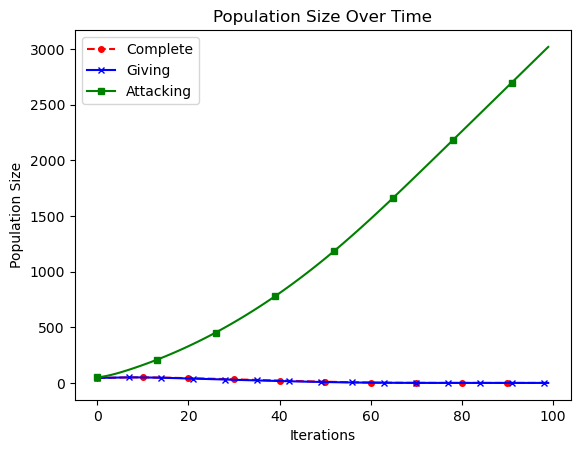

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 449.4072265625
Population 2: random - 45.150997161865234
Population 3: random - 45.44796371459961

Total fitness: 540.0061645507812

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.22%
Population 2: random - 8.36%
Population 3: random - 8.42%



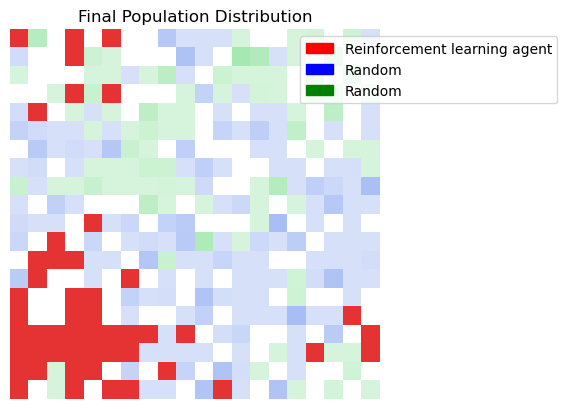

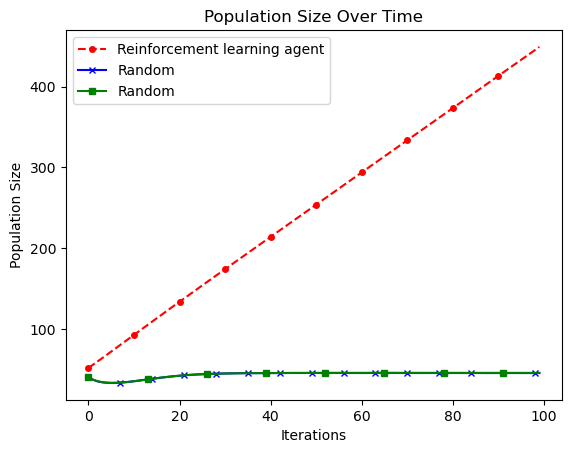

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 516.852294921875
Population 2: giving - 107.55242156982422
Population 3: giving - 107.86489868164062

Total fitness: 732.2696533203125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 70.58%
Population 2: giving - 14.69%
Population 3: giving - 14.73%



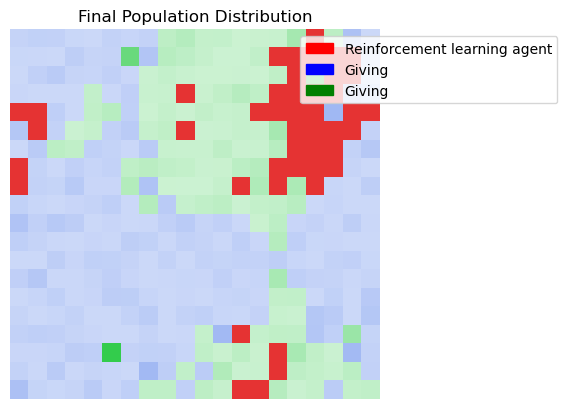

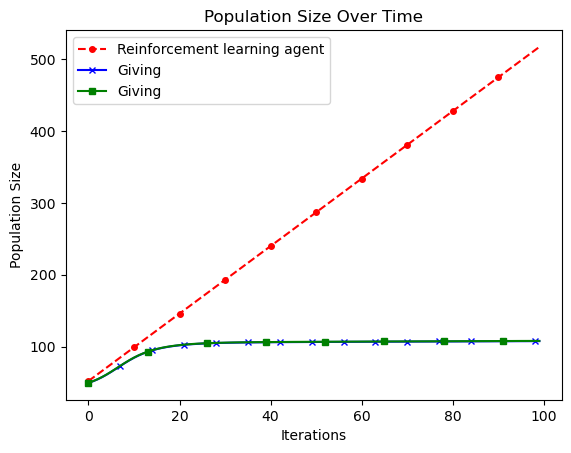

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.864149808883667
Population 2: attacking - 1265.9190673828125
Population 3: attacking - 1279.9462890625

Total fitness: 2546.7294921875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.03%
Population 2: attacking - 49.71%
Population 3: attacking - 50.26%



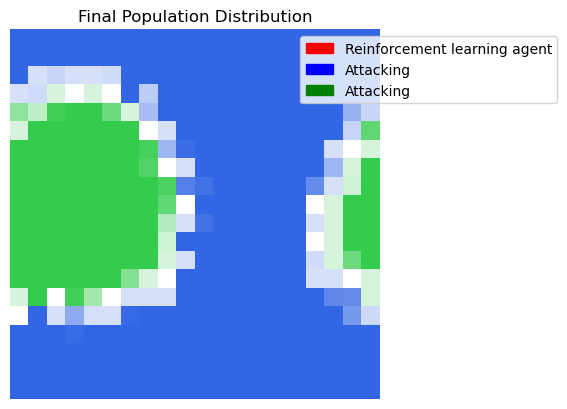

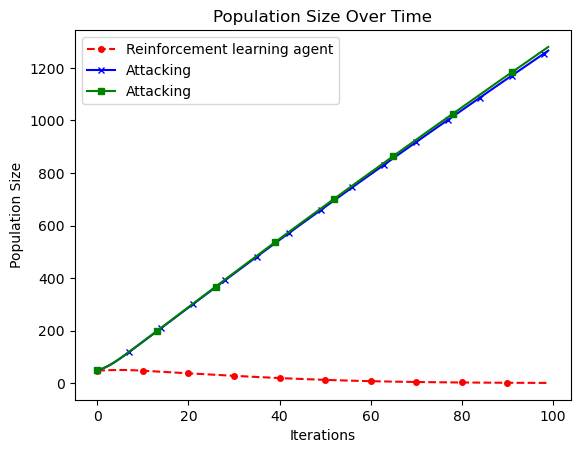

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.29529571533203
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.29529571533203

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



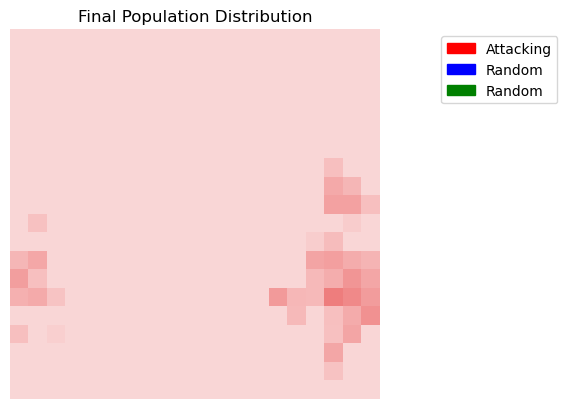

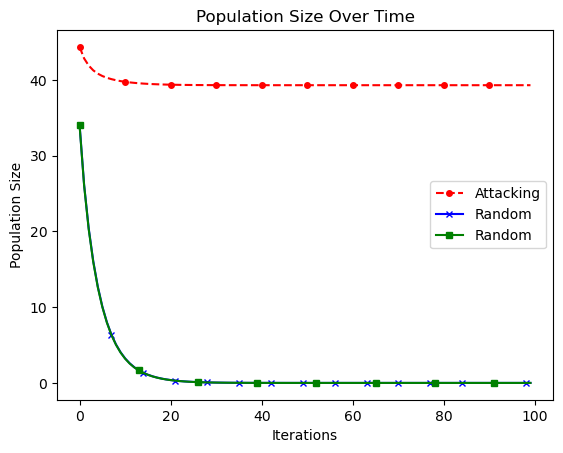

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 6.851525995443808e-07
Population 2: random - 1.2253399290784728e-05
Population 3: random - 1.1721313057933003e-05

Total fitness: 2.4659864720888436e-05

Final population %'s fitness:
Population 1: giving - 2.78%
Population 2: random - 49.69%
Population 3: random - 47.53%



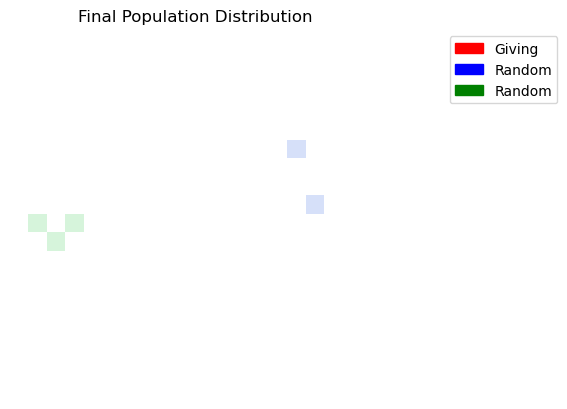

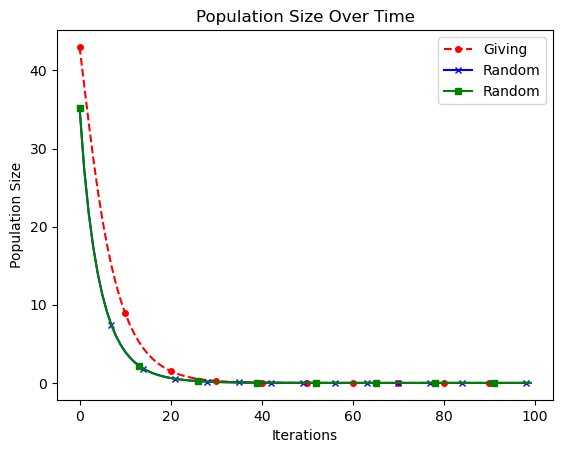

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 1.2783668523752567e-07
Population 2: random - 6.03206126470468e-06
Population 3: random - 5.998540473228786e-06

Total fitness: 1.2158438039477915e-05

Final population %'s fitness:
Population 1: complete - 1.05%
Population 2: random - 49.61%
Population 3: random - 49.34%



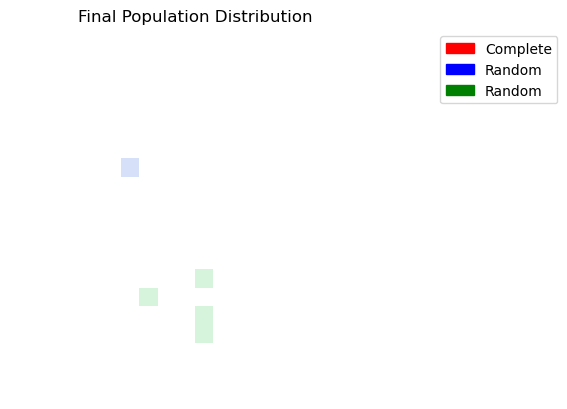

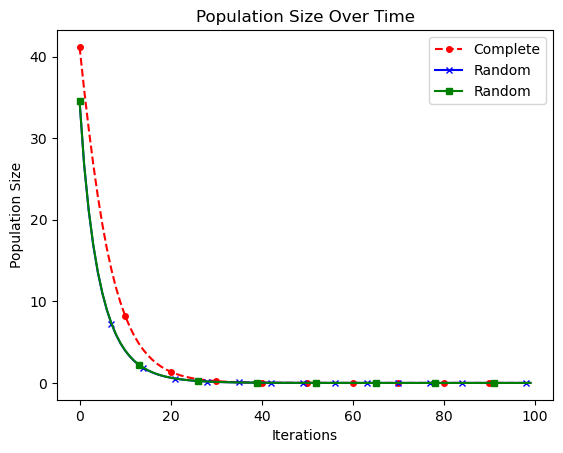

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 4.513188045507377e-08
Population 2: giving - 0.0
Population 3: attacking - 33.445556640625

Total fitness: 33.445556640625

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



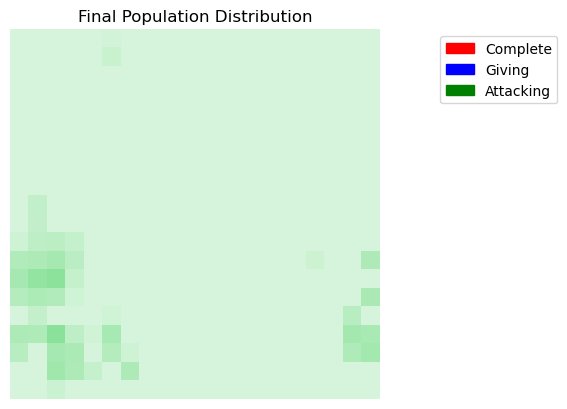

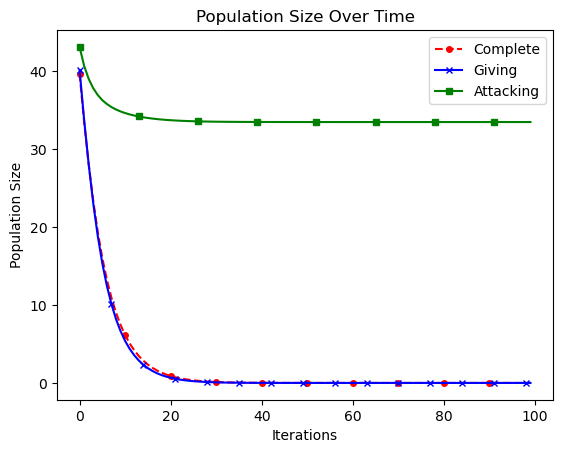

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.261699914932251..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.31913757324219
Population 2: random - 8.76558533491334e-06
Population 3: random - 1.1575147254916374e-05

Total fitness: 44.319156646728516

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



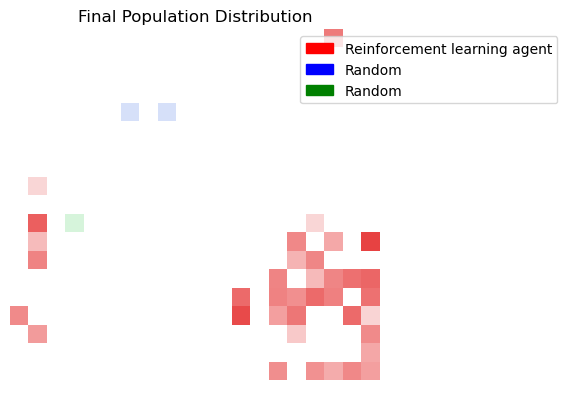

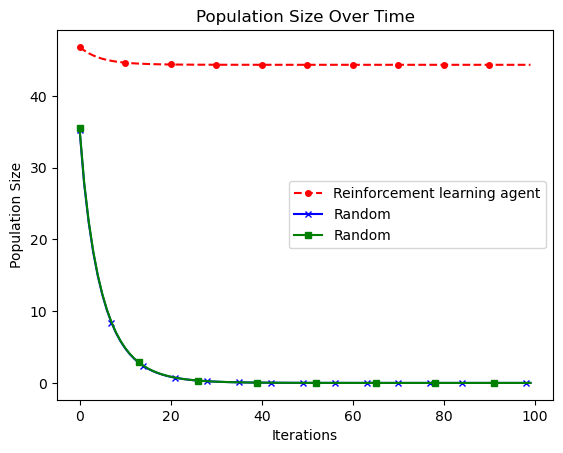

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.508501386642456..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 47.345462799072266
Population 2: giving - 0.0359468013048172
Population 3: giving - 0.038827549666166306

Total fitness: 47.42023468017578

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.84%
Population 2: giving - 0.08%
Population 3: giving - 0.08%



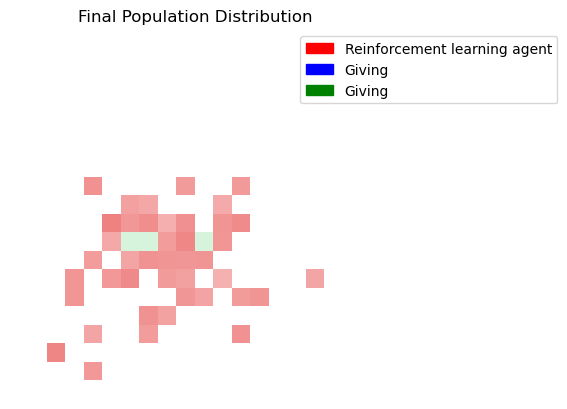

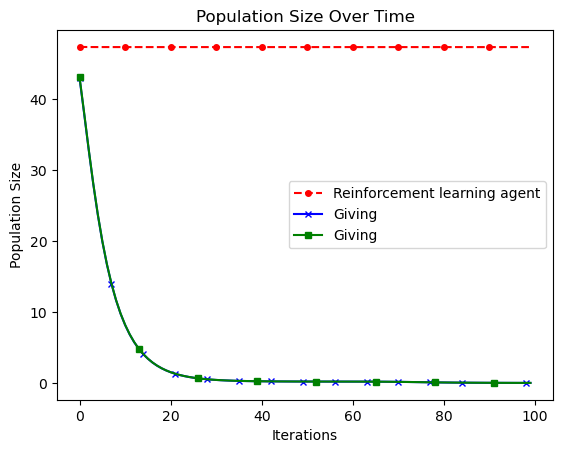

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5074602603912354..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 20.983366012573242
Population 2: attacking - 26.63777732849121
Population 3: attacking - 26.29962158203125

Total fitness: 73.92076110839844

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.39%
Population 2: attacking - 36.04%
Population 3: attacking - 35.58%



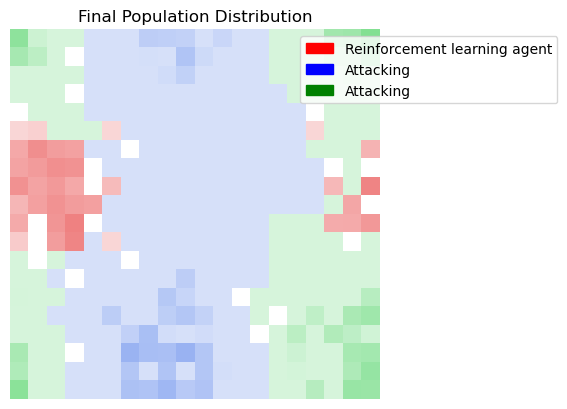

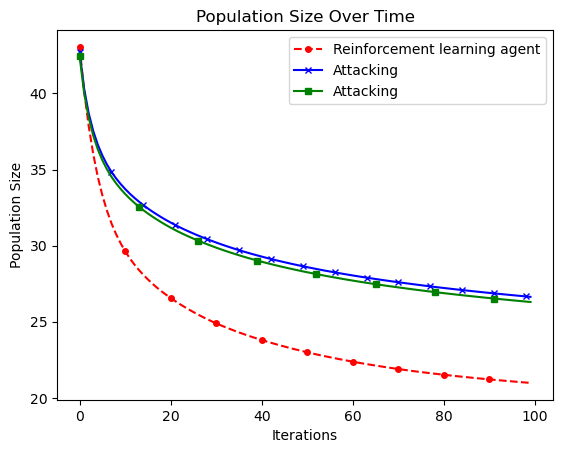

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7206.70849609375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7206.70849609375

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



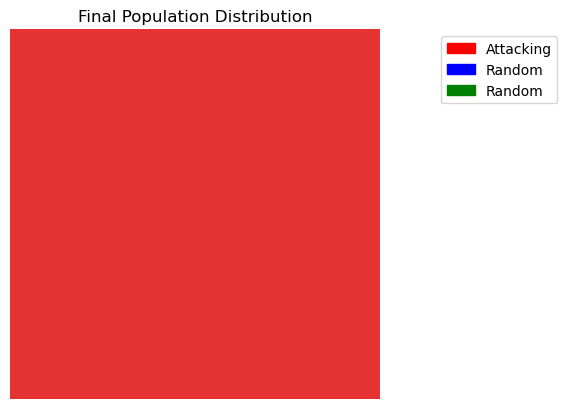

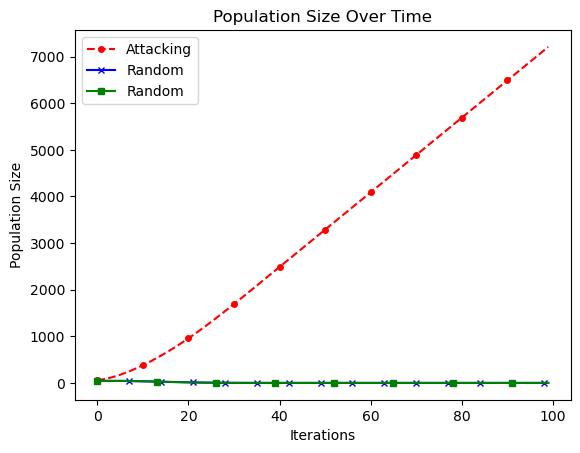

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 450.01824951171875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 450.01824951171875

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



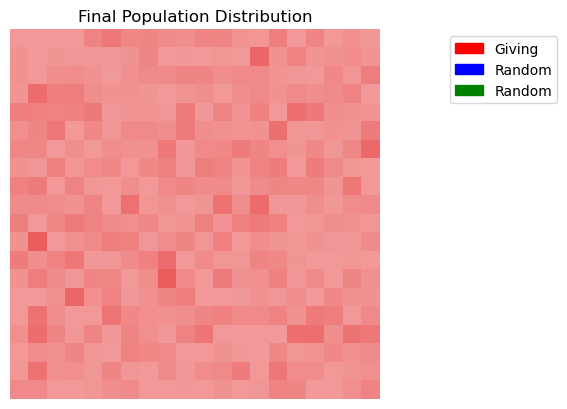

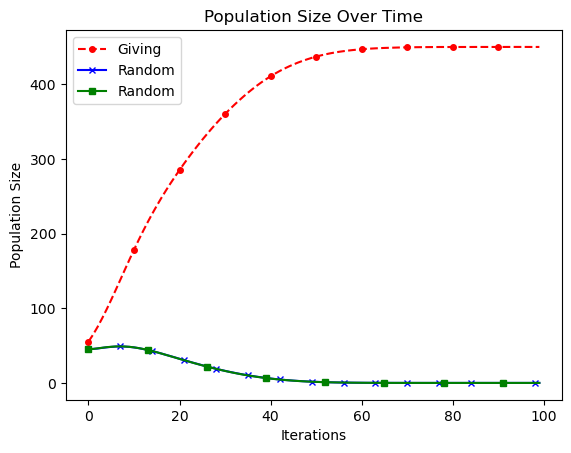

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 450.00830078125
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 450.00830078125

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



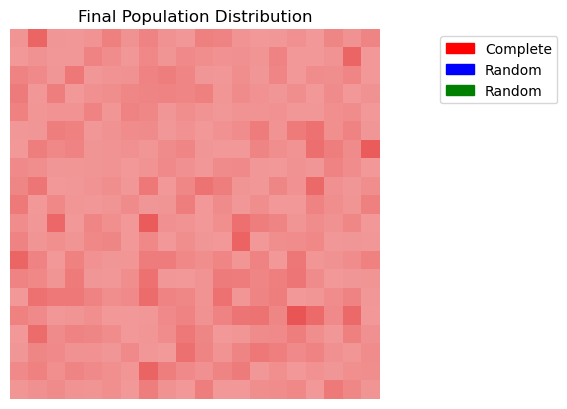

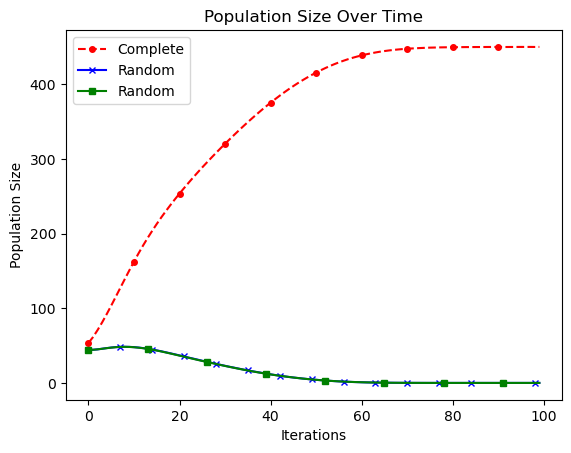

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.006844236049801111
Population 2: giving - 0.003204758744686842
Population 3: attacking - 6007.6640625

Total fitness: 6007.67431640625

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



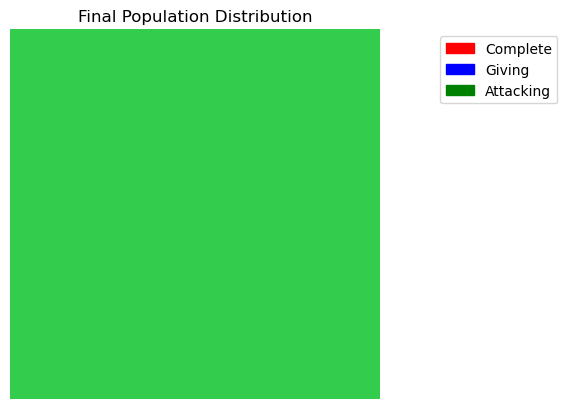

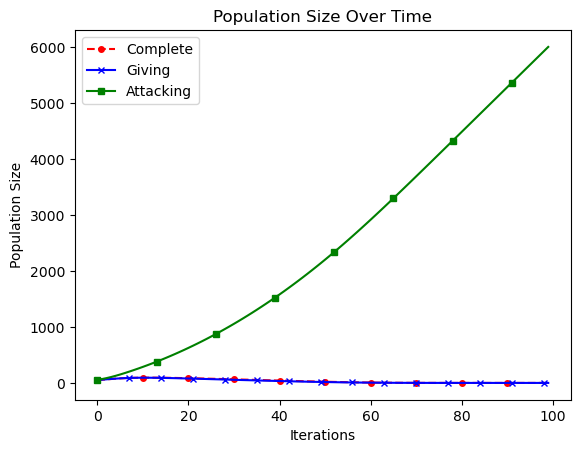

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 853.4109497070312
Population 2: random - 90.76749420166016
Population 3: random - 90.60868835449219

Total fitness: 1034.787109375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.47%
Population 2: random - 8.77%
Population 3: random - 8.76%



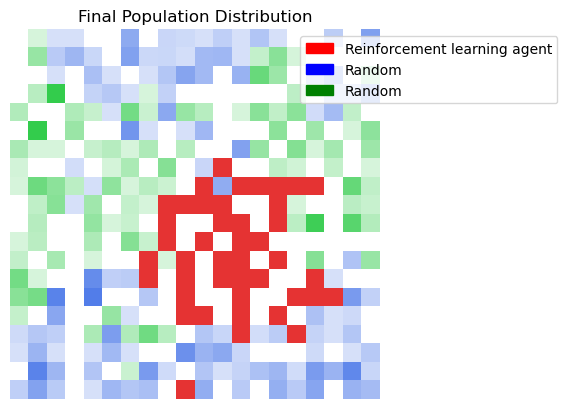

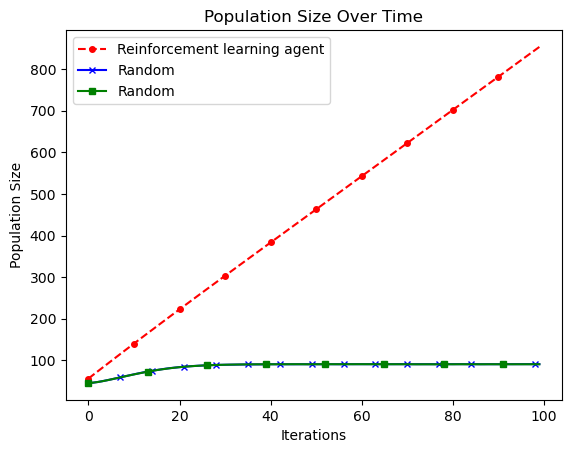

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 987.128662109375
Population 2: giving - 214.6845703125
Population 3: giving - 215.42584228515625

Total fitness: 1417.239013671875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 69.65%
Population 2: giving - 15.15%
Population 3: giving - 15.20%



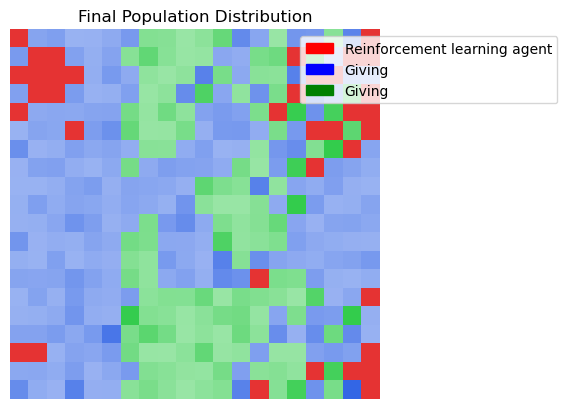

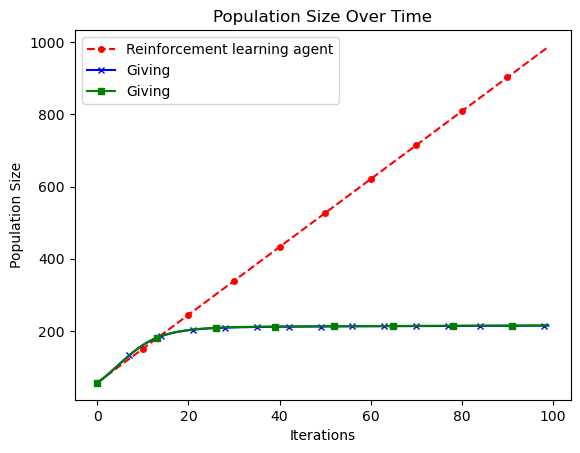

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.47301405668258667
Population 2: attacking - 2531.202392578125
Population 3: attacking - 2533.64501953125

Total fitness: 5065.3203125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.01%
Population 2: attacking - 49.97%
Population 3: attacking - 50.02%



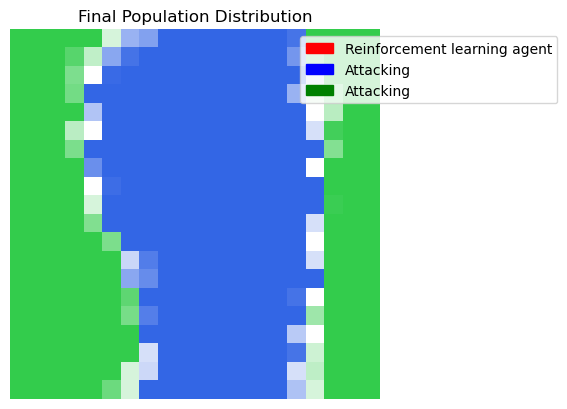

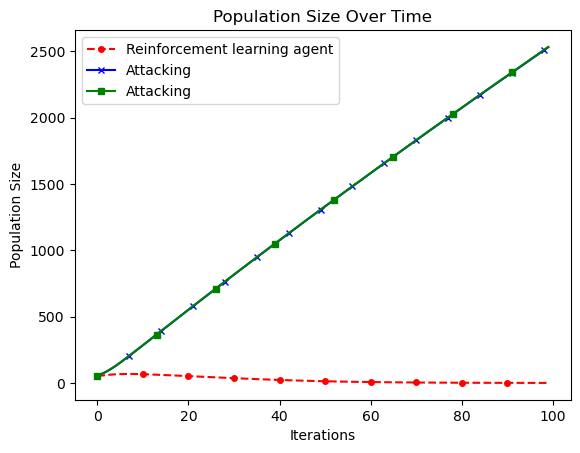

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7207.3046875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7207.3046875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



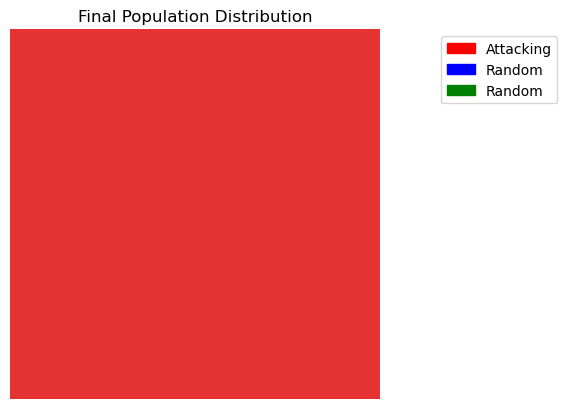

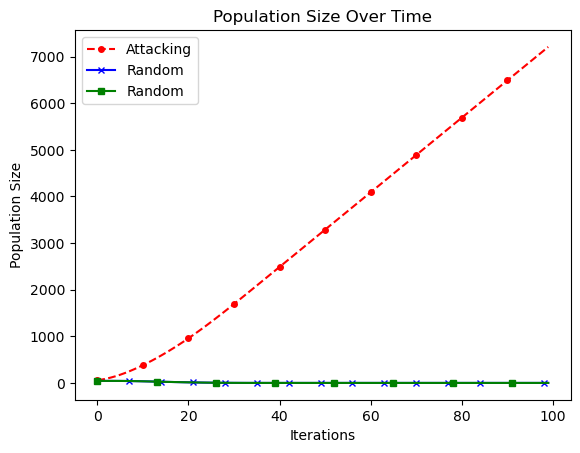

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 449.939697265625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.939697265625

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



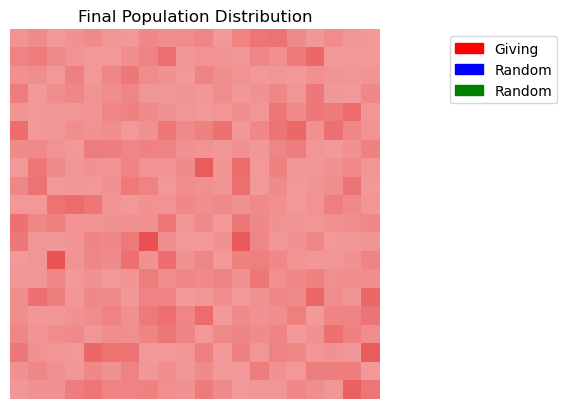

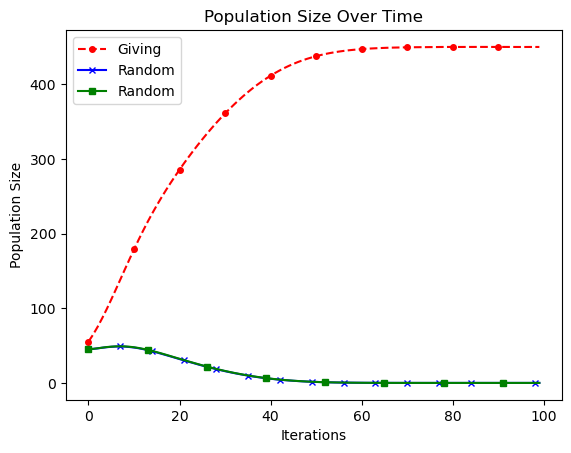

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 450.0058288574219
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 450.0058288574219

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



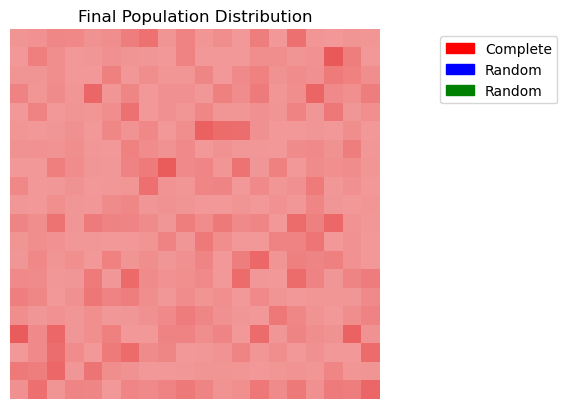

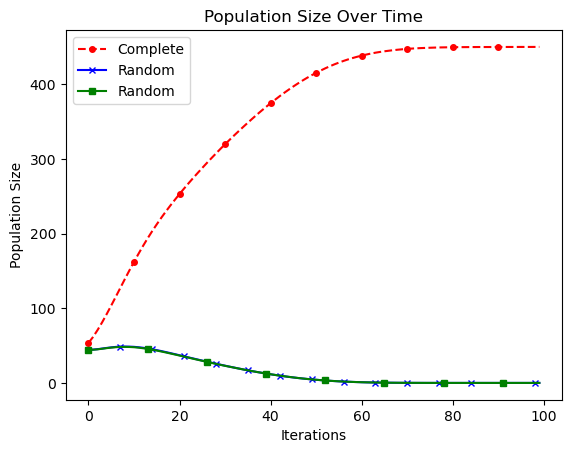

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.015816979110240936
Population 2: giving - 0.02488761767745018
Population 3: attacking - 6013.63525390625

Total fitness: 6013.67578125

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



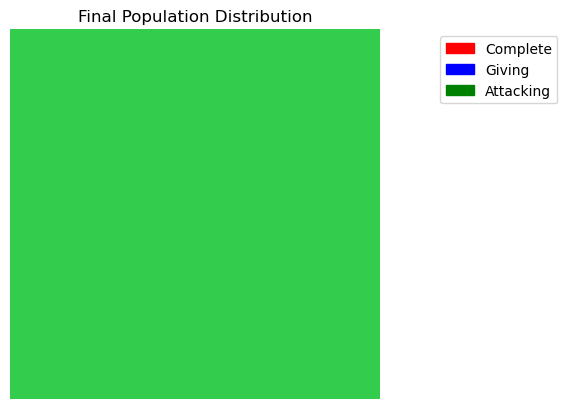

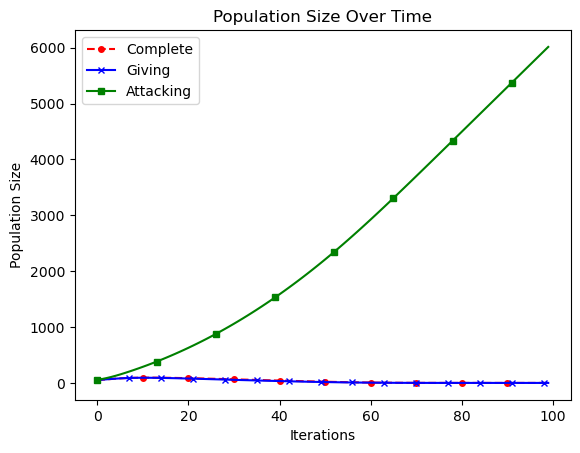

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 846.6011962890625
Population 2: random - 91.35836791992188
Population 3: random - 90.31806182861328

Total fitness: 1028.2777099609375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.33%
Population 2: random - 8.88%
Population 3: random - 8.78%



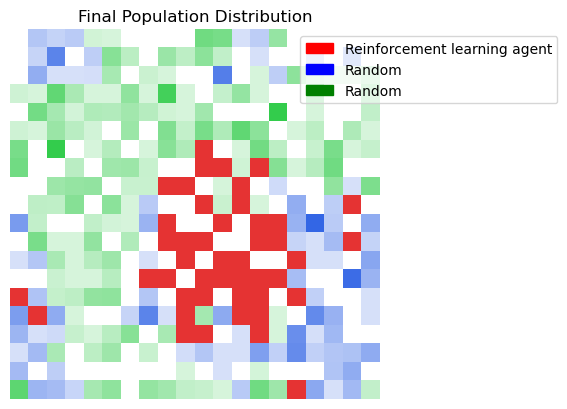

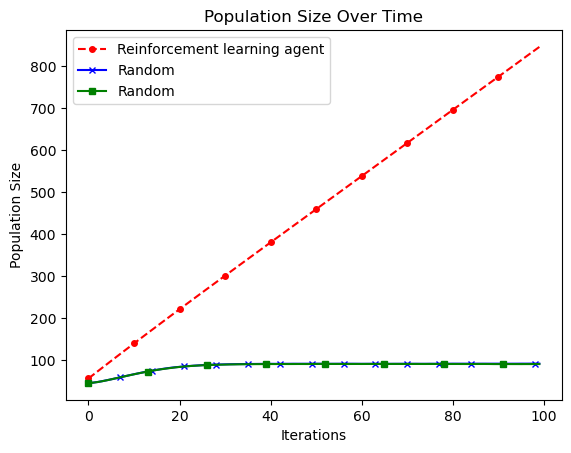

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 987.8410034179688
Population 2: giving - 215.21629333496094
Population 3: giving - 215.3637237548828

Total fitness: 1418.4210205078125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 69.64%
Population 2: giving - 15.17%
Population 3: giving - 15.18%



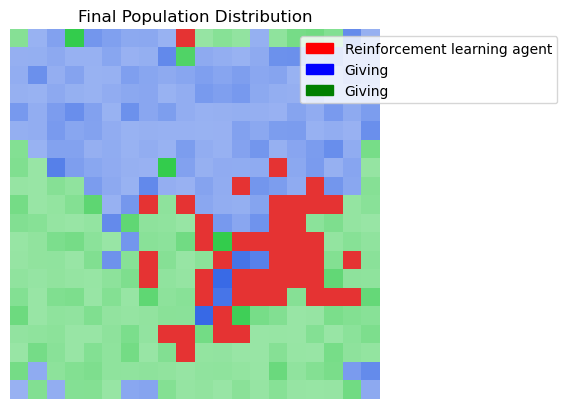

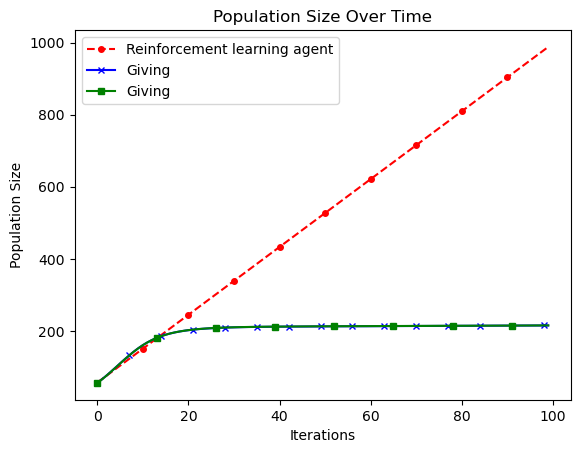

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.4765675663948059
Population 2: attacking - 2527.5478515625
Population 3: attacking - 2537.033935546875

Total fitness: 5065.05859375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.01%
Population 2: attacking - 49.90%
Population 3: attacking - 50.09%



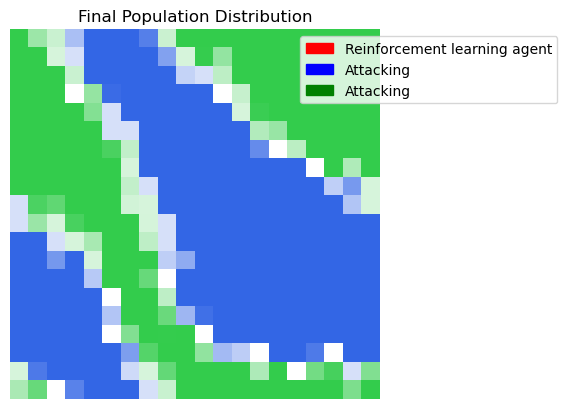

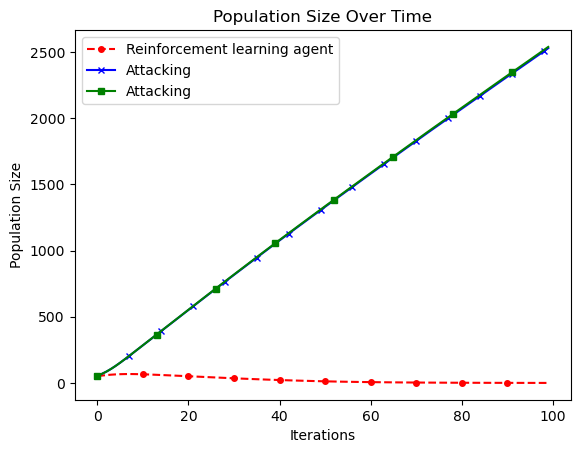

In [9]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 100

# Simulation parameters
nb_batches = 5000
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Complete vs Giving vs Attacking\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Random"
    print("Creating simulation: Reinforcement Learning Agent vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='random', type3='random', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Attacker")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsAttacker')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='giving', type3='giving', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Giving\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Giving")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsGiving')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='attacking', type3='attacking', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Attacker\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
